In [1]:
import pandas as pd
import matplotlib.pyplot as mp
import seaborn as sb
import os
from sklearn.cluster import KMeans



In [2]:
dataset = pd.read_csv("Mall_Customers.csv")
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
fields = dataset.iloc[:,[3,4]].values
fields

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

In [4]:
import warnings
warnings.filterwarnings("ignore")


In [5]:
wcss = []

for index in range(1,11):
    kmeans = KMeans(n_clusters = index, init = "k-means++", random_state = 2)
    kmeans.fit(fields)

    wcss.append(kmeans.inertia_)

  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


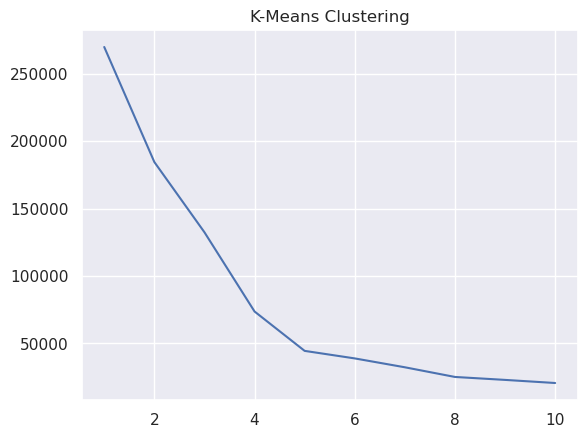

In [6]:
#Graficación del "Codo de Jambu"
sb.set()
mp.plot(range(1,11),wcss)
mp.title("K-Means Clustering")
mp.xlabel= ("Número de clusteres")
mp.ylabel = ("WCSS")


In [7]:
kmeans = KMeans(n_clusters = 5, init = "k-means++", random_state = 42)
cluster_values = kmeans.fit_predict(fields)
print(cluster_values)

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


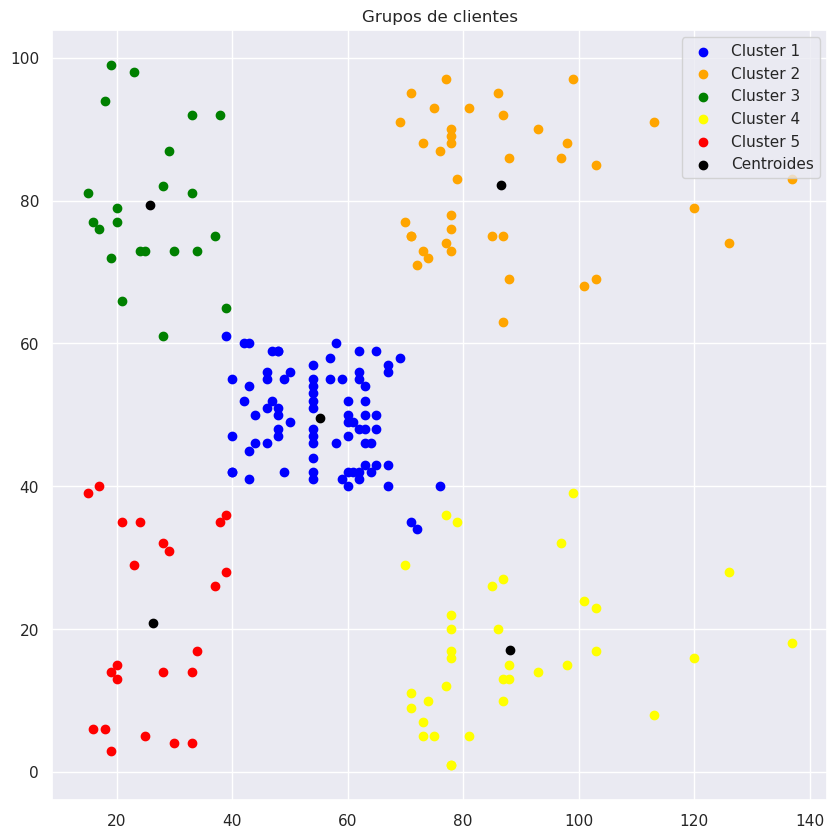

In [8]:
mp.figure(figsize=(10,10))
mp.scatter(fields[cluster_values == 0,0],fields[cluster_values==0,1], c= 'blue', label='Cluster 1')
mp.scatter(fields[cluster_values == 1,0],fields[cluster_values==1,1], c= 'orange', label='Cluster 2')
mp.scatter(fields[cluster_values == 2,0],fields[cluster_values==2,1], c= 'green', label='Cluster 3')
mp.scatter(fields[cluster_values == 3,0],fields[cluster_values==3,1], c= 'yellow', label='Cluster 4')
mp.scatter(fields[cluster_values == 4,0],fields[cluster_values==4,1], c= 'red', label='Cluster 5')

mp.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1], c='black', label='Centroides')

mp.title("Grupos de clientes")
mp.xlabel = 'Annual income'
mp.ylabel = 'Spending Score'
mp.legend()

In [9]:
#Criterio de silueta ("Silhouette")
from sklearn import datasets
from sklearn.metrics import silhouette_score


In [10]:
X= dataset.iloc[:,[3,4]].to_numpy()
for j in range (2,12):
    kmeans = KMeans(n_clusters = j, random_state =42)
    kmeans.fit_predict(X)
    #Calcular el Score de Silueta
    score = silhouette_score (X, kmeans.labels_, metric="euclidean")
    print("Score Silhouete;","k=",j, ":" ,score)

Score Silhouete; k= 2 : 0.39564531743995546
Score Silhouete; k= 3 : 0.46761358158775435
Score Silhouete; k= 4 : 0.4937945814354117
Score Silhouete; k= 5 : 0.553931997444648
Score Silhouete; k= 6 : 0.5128405328004378
Score Silhouete; k= 7 : 0.5017174409749505
Score Silhouete; k= 8 : 0.4962769338093321
Score Silhouete; k= 9 : 0.45587414130065596
Score Silhouete; k= 10 : 0.4426214845978157
Score Silhouete; k= 11 : 0.41413838935154096


In [11]:
#Algoritmo KMeans aplicado a 3 columnas de nuestra base original
#bajo una transformación de PCA

fields2 = dataset.iloc[:,[2,3,4]].values
fields2

array([[ 19,  15,  39],
       [ 21,  15,  81],
       [ 20,  16,   6],
       [ 23,  16,  77],
       [ 31,  17,  40],
       [ 22,  17,  76],
       [ 35,  18,   6],
       [ 23,  18,  94],
       [ 64,  19,   3],
       [ 30,  19,  72],
       [ 67,  19,  14],
       [ 35,  19,  99],
       [ 58,  20,  15],
       [ 24,  20,  77],
       [ 37,  20,  13],
       [ 22,  20,  79],
       [ 35,  21,  35],
       [ 20,  21,  66],
       [ 52,  23,  29],
       [ 35,  23,  98],
       [ 35,  24,  35],
       [ 25,  24,  73],
       [ 46,  25,   5],
       [ 31,  25,  73],
       [ 54,  28,  14],
       [ 29,  28,  82],
       [ 45,  28,  32],
       [ 35,  28,  61],
       [ 40,  29,  31],
       [ 23,  29,  87],
       [ 60,  30,   4],
       [ 21,  30,  73],
       [ 53,  33,   4],
       [ 18,  33,  92],
       [ 49,  33,  14],
       [ 21,  33,  81],
       [ 42,  34,  17],
       [ 30,  34,  73],
       [ 36,  37,  26],
       [ 20,  37,  75],
       [ 65,  38,  35],
       [ 24,  38

In [12]:
from sklearn import decomposition

pca = decomposition.PCA(n_components=2)
pca.fit(fields2)
fields2 = pca.transform(fields2)
fields2

array([[-3.18705078e+01, -3.30014253e+01],
       [ 7.63396908e-01, -5.68438653e+01],
       [-5.74087256e+01, -1.31229362e+01],
       [-2.16989648e+00, -5.34779049e+01],
       [-3.21749197e+01, -3.03870050e+01],
       [-2.17827777e+00, -5.22265808e+01],
       [-5.90660565e+01, -9.54170669e+00],
       [ 1.23693261e+01, -6.16176843e+01],
       [-6.63156568e+01, -3.21359934e+00],
       [-5.65677534e+00, -4.72664534e+01],
       [-5.82366179e+01, -9.13375312e+00],
       [ 1.46202592e+01, -6.21072940e+01],
       [-5.51612126e+01, -1.00779778e+01],
       [-4.30660584e-03, -5.01134367e+01],
       [-5.27647474e+01, -1.16804199e+01],
       [ 1.94563480e+00, -5.15231943e+01],
       [-3.45062349e+01, -2.37600734e+01],
       [-7.30573032e+00, -4.35158724e+01],
       [-4.12574933e+01, -1.64734320e+01],
       [ 1.61888268e+01, -5.82998775e+01],
       [-3.27403118e+01, -2.13349462e+01],
       [-9.82702739e-01, -4.44533143e+01],
       [-5.78102821e+01, -1.86854579e+00],
       [-1.

In [13]:
wcss2 = []

for index in range(1,11):
    kmeans = KMeans(n_clusters = index, init = "k-means++", random_state = 2)
    kmeans.fit(fields2)

    wcss2.append(kmeans.inertia_)

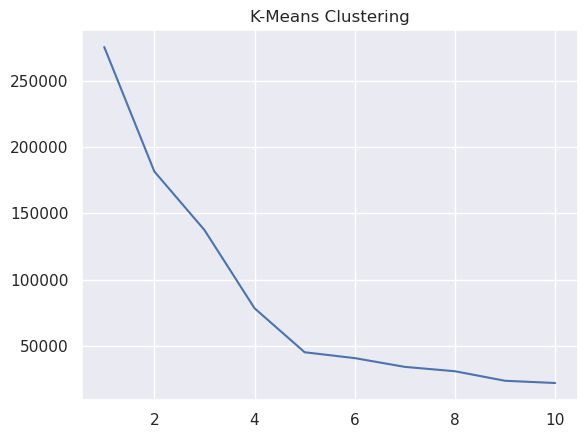

In [14]:
# Graficación del "Codo de Jambu"
sb.set()
mp.plot(range(1,11), wcss2)
mp.title("K-Means Clustering")
mp.xlabel= ("Número de clusteres")
mp.ylabel = ("WCSS")


In [15]:
kmeans = KMeans(n_clusters = 5, init = "k-means++", random_state = 42)
cluster_values = kmeans.fit_predict(fields2)
print(cluster_values)

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


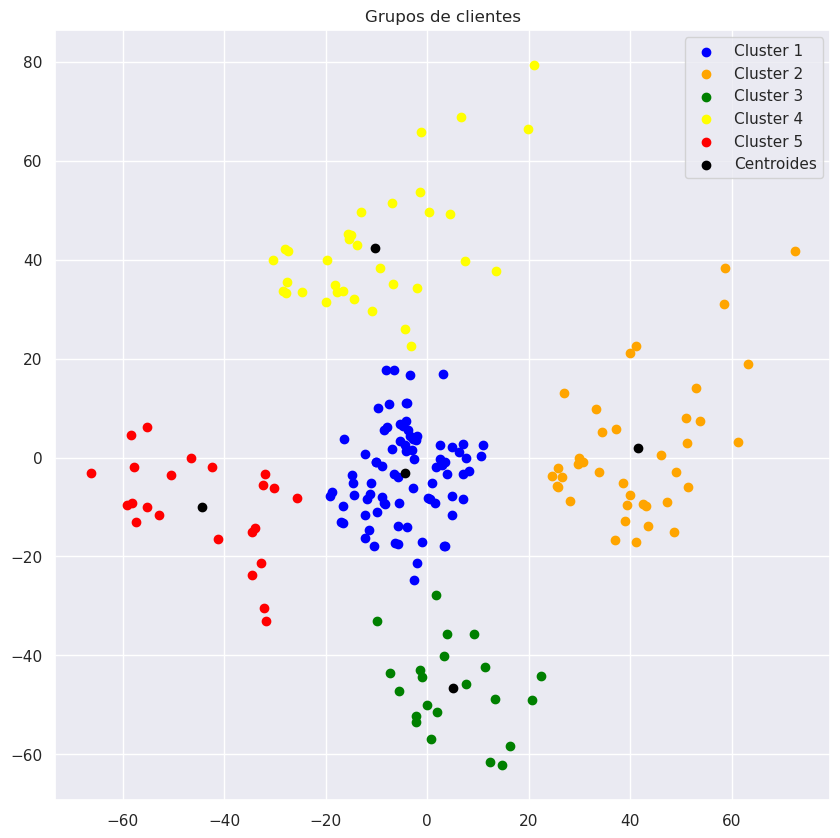

In [16]:
mp.figure(figsize=(10,10))

mp.scatter(fields2[cluster_values==0,0], fields2[cluster_values==0,1], c='blue', label='Cluster 1')
mp.scatter(fields2[cluster_values==1,0], fields2[cluster_values==1,1], c='orange', label='Cluster 2')
mp.scatter(fields2[cluster_values==2,0], fields2[cluster_values==2,1], c='green', label='Cluster 3')
mp.scatter(fields2[cluster_values==3,0], fields2[cluster_values==3,1], c='yellow', label='Cluster 4')
mp.scatter(fields2[cluster_values==4,0], fields2[cluster_values==4,1], c='red', label='Cluster 5')

mp.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c='black', label='Centroides')

mp.title("Grupos de clientes")
mp.xlabel=("Annual income")
mp.ylabel=("Spending Score")
mp.legend()